---
**GUIA DE LABORATORIO 4 - Derivada y Gradiente**  
**Nombre:** Roberto Roly Copa Mamani  
**Materia:** Machine Learning - INF 672

---

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

INDIGO  = "#4F46E5"
PURPURA = "#7E22CE"
CORAL   = "#F43F5E"
TINTA   = "#111827"

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"]      = True
plt.rcParams["grid.alpha"]     = 0.3
plt.rcParams["font.size"]      = 11
plt.rcParams["axes.edgecolor"] = "#9CA3AF"

print("Entorno listo ✓")

Entorno listo ✓


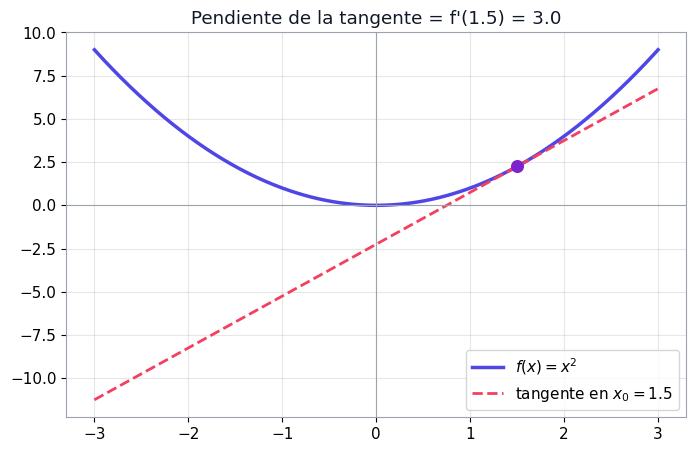

In [6]:
f  = lambda x: x**2
fp = lambda x: 2*x

x0 = 1.5
x  = np.linspace(-3, 3, 400)
tangente = f(x0) + fp(x0) * (x - x0)
plt.plot(x, f(x), color=INDIGO, lw=2.5, label=r"$f(x)=x^2$")
plt.plot(x, tangente, color=CORAL, lw=2, ls="--",
label=fr"tangente en $x_0={x0}$")
plt.scatter([x0], [f(x0)], color=PURPURA, s=70, zorder=5)
plt.axhline(0, color="#9CA3AF", lw=0.8); plt.axvline(0, color="#9CA3AF", lw=0.8)
plt.title(f"Pendiente de la tangente = f'({x0}) = {fp(x0)}", color=TINTA)
plt.legend(); plt.show()

la tangente toca a la parábola en un único punto y su pendiente es 3.0, exactamente el valor de f'(1.5). La derivada representa la pendiente instantánea

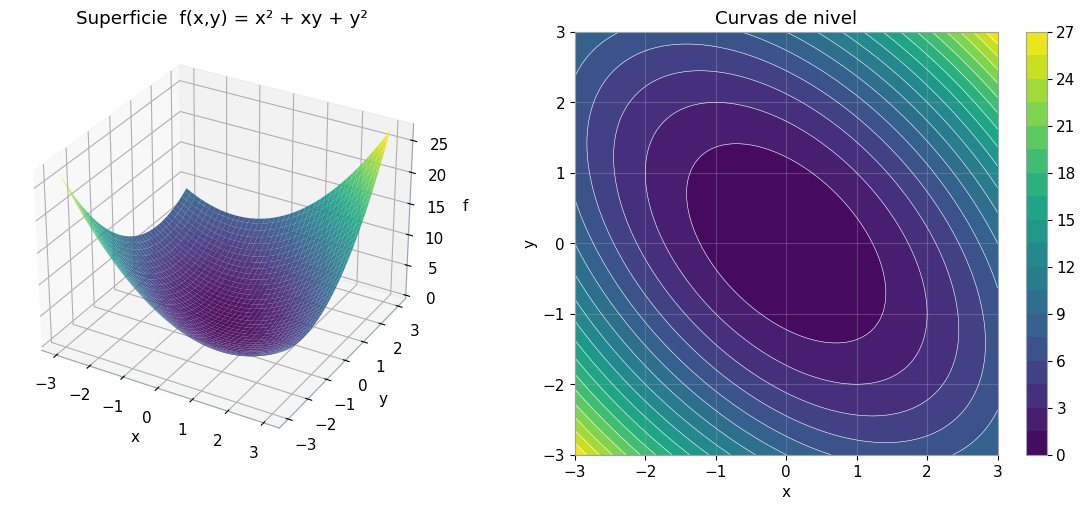

In [7]:
f2 = lambda x, y: x**2 + x*y + y**2

x = np.linspace(-3, 3, 120)
y = np.linspace(-3, 3, 120)
X, Y = np.meshgrid(x, y)
Z = f2(X, Y)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(X, Y, Z, cmap="viridis", alpha=0.92)
ax1.set_title("Superficie  f(x,y) = x² + xy + y²")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("f")

ax2 = fig.add_subplot(1, 2, 2)
cs = ax2.contourf(X, Y, Z, levels=20, cmap="viridis")
ax2.contour(X, Y, Z, levels=20, colors="white", linewidths=0.4)
ax2.set_title("Curvas de nivel"); ax2.set_xlabel("x"); ax2.set_ylabel("y")
ax2.set_aspect("equal")
fig.colorbar(cs, ax=ax2)
plt.tight_layout(); plt.show()

la superficie tiene forma de tazón y el mapa muestra el mismo comportamiento desde arriba. Las elipses concéntricas indican que el mínimo está en (0,0)

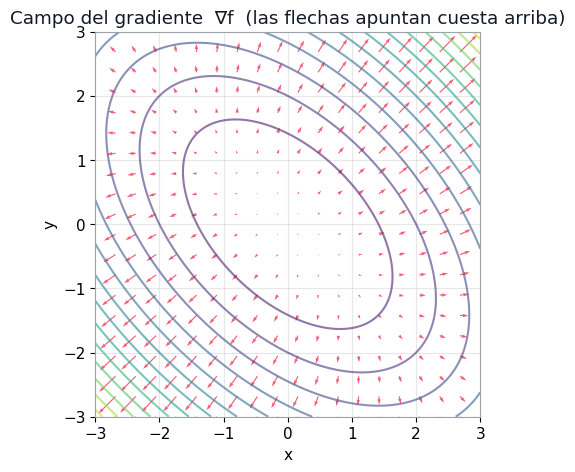

In [8]:
def grad_f2(x, y):
  return 2*x + y, x + 2*y

xg = np.linspace(-3, 3, 20)
yg = np.linspace(-3, 3, 20)
Xg, Yg = np.meshgrid(xg, yg)
U, V = grad_f2(Xg, Yg)

xf = np.linspace(-3, 3, 200); yf = np.linspace(-3, 3, 200)
Xf, Yf = np.meshgrid(xf, yf); Zf = f2(Xf, Yf)
plt.contour(Xf, Yf, Zf, levels=15, cmap="viridis", alpha=0.6)
plt.quiver(Xg, Yg, U, V, color=CORAL, alpha=0.85)
plt.title("Campo del gradiente  ∇f  (las flechas apuntan cuesta arriba)", color=TINTA)
plt.xlabel("x"); plt.ylabel("y"); plt.gca().set_aspect("equal")
plt.show()

las flechas son perpendiculares a las curvas de nivel y apuntan hacia donde la función crece más rápido. Cerca del origen son pequeñas porque el gradiente se aproxima a cero

In [9]:
f3      = lambda x, y: x**2 + y**2
grad_f3 = lambda x, y: np.array([2*x, 2*y])

punto = np.array([4.0, 4.0])
alpha = 0.1
trayectoria = [punto.copy()]

for _ in range(25):
    punto = punto - alpha * grad_f3(*punto)
    trayectoria.append(punto.copy())

trayectoria = np.array(trayectoria)
print("Primeros puntos:")
for i, p in enumerate(trayectoria[:3]):
    print(f"  x_{i} = ({p[0]:.3f}, {p[1]:.3f})")
print(f"  ...\n  x_25 = ({trayectoria[-1,0]:.4f}, {trayectoria[-1,1]:.4f})")

Primeros puntos:
  x_0 = (4.000, 4.000)
  x_1 = (3.200, 3.200)
  x_2 = (2.560, 2.560)
  ...
  x_25 = (0.0151, 0.0151)


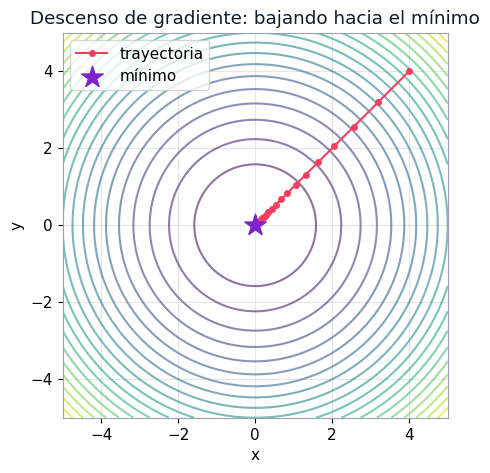

In [10]:
xf = np.linspace(-5, 5, 200); yf = np.linspace(-5, 5, 200)
Xf, Yf = np.meshgrid(xf, yf); Zf = f3(Xf, Yf)
plt.contour(Xf, Yf, Zf, levels=20, cmap="viridis", alpha=0.6)
plt.plot(trayectoria[:, 0], trayectoria[:, 1], "o-", color=CORAL, ms=4, lw=1.5,
label="trayectoria")
plt.scatter([0], [0], marker="*", s=260, color=PURPURA, zorder=5, label="mínimo")
plt.title("Descenso de gradiente: bajando hacia el mínimo", color=TINTA)
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.gca().set_aspect("equal")
plt.show()

los pasos son grandes al inicio y se acortan cerca de (0,0) porque el gradiente disminuye. Con alpha=0.1 la trayectoria converge de forma estable al mínimo

**E2.** Repite la Visualización 1 para una función distinta, g(x) = x³ − 3x, con su derivada gʹ(x) = 3x² − 3 (derívala a mano) y dibuja la tangente en x₀ = 1

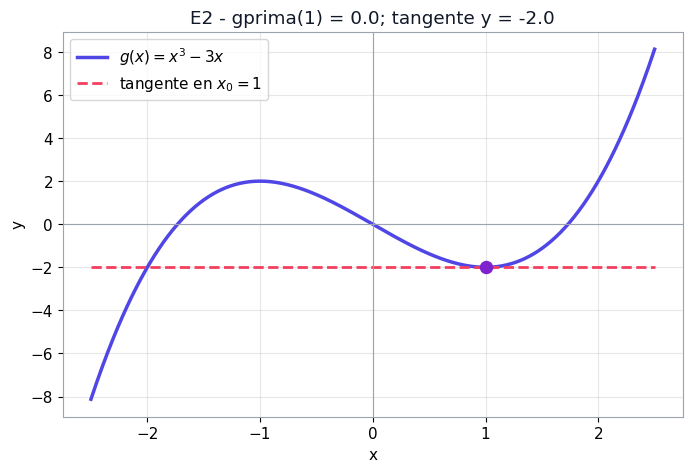

In [4]:
g = lambda x: x**3 - 3*x
gp = lambda x: 3*x**2 - 3
x0_g = 1.0;
x = np.linspace(-2.5, 2.5, 500)
tangente_g = g(x0_g) + gp(x0_g) * (x - x0_g)
plt.figure()
plt.plot(x, g(x), color=INDIGO, lw=2.5, label=r'$g(x)=x^3-3x$')
plt.plot(x, tangente_g, '--', color=CORAL, lw=2, label=r'tangente en $x_0=1$')
plt.scatter([x0_g], [g(x0_g)], color=PURPURA, s=75, zorder=5)
plt.axhline(0, color='#9CA3AF', lw=0.8); plt.axvline(0, color='#9CA3AF', lw=0.8)
plt.title(f'E2 - gprima(1) = {gp(x0_g):.1f}; tangente y = {g(x0_g):.1f}', color=TINTA)
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.show()

**E3.** En el descenso de gradiente, cambia el punto inicial a (−4, 3) y comenta cómo cambia la trayectoria hacia el mínimo.

Inicio: [-4.  3.] | Final: [-0.01511157  0.01133368]


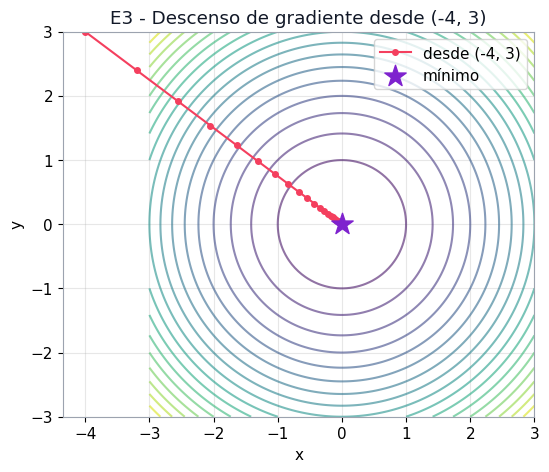

In [14]:
punto_e3 = np.array([-4.0, 3.0]); trayectoria_e3 = [punto_e3.copy()]
for _ in range(25):
    punto_e3 = punto_e3 - 0.1 * grad_f3(*punto_e3)
    trayectoria_e3.append(punto_e3.copy())
trayectoria_e3 = np.array(trayectoria_e3)
print(f'Inicio: {trayectoria_e3[0]} | Final: {trayectoria_e3[-1]}')
plt.figure()
plt.contour(X, Y, f3(X, Y), levels=20, cmap='viridis', alpha=0.6)
plt.plot(trayectoria_e3[:, 0], trayectoria_e3[:, 1], 'o-', color=CORAL, ms=4, label='desde (-4, 3)')
plt.scatter([0], [0], marker='*', s=260, color=PURPURA, zorder=5, label='mínimo')
plt.title('E3 - Descenso de gradiente desde (-4, 3)', color=TINTA)
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.gca().set_aspect('equal'); plt.show()

la trayectoria empieza en el tercer cuadrante y se dirige diagonalmente al origen. La forma de las curvas de nivel no cambia; solo cambia el punto de partida y, por eso, el lado desde el que se aproxima al mínimo

**E4.** Escribe en una celda Markdown tu respuesta, con tus propias palabras, a la pregunta del cuaderno: ¿cómo sabe un modelo hacia qué lado mover cada parámetro para reducir el error?

Un modelo calcula el gradiente del error con respecto a cada parámetro. Cada componente indica cómo cambia el error si ese parámetro aumenta un poco: el signo señala el sentido y la magnitud indica qué tan sensible es el error. Durante el entrenamiento, el modelo resta una fracción del gradiente (parámetro nuevo = parámetro actual - tasa de aprendizaje × gradiente), por lo que mueve cada parámetro en la dirección que reduce el error. Repite este proceso con muchos ejemplos hasta acercarse a un mínimo; la tasa de aprendizaje controla el tamaño de los pasos y debe ser suficientemente pequeña para no saltar el mínimo